# 03 - Train Walker2d-v5

This notebook contains the full training workflow for `Walker2d-v5`.

Environment context:

Walker2d is a two-legged walking task. The policy has to coordinate a larger body and remain upright while moving forward. This environment is more sensitive to unstable policies, so fall rate and seed-to-seed variance are especially important.

In this notebook we:

- train the default 1M-step baseline runs
- run the shorter tuned-screening experiments
- select the tuned setting for each algorithm
- train the final tuned 1M-step runs
- check checkpoint/final-model state before every run
- plot learning curves for this environment
- summarize the final evaluation results for this environment

Main focus for `Walker2d-v5`:

- test whether each algorithm can learn a stable gait
- watch how fall rate changes after longer training
- compare robustness under noisy actions after the policy has learned

## Load project code

We start by locating the project root and importing the shared utility module.  
The utility file contains the environment list, algorithm list, hyperparameter
configs, checkpoint handling, evaluation helpers, plotting helpers, and registry
functions used throughout the project.

This keeps the notebook readable while still leaving the full experiment logic in
the notebook cells below.

In [1]:
from pathlib import Path
import os, sys, time, json

def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent, Path(r"D:/MuJoCo_RL_Project")]:
        if (candidate / "project_utils.py").exists():
            return candidate.resolve()
    raise RuntimeError("project_utils.py was not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

import project_utils as pu
pu.set_plot_style()
pu.ensure_dirs()

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")


[project_utils] Loaded - Project root: D:\MuJoCo_RL_Project
  Python 3.10.20 | SB3 2.9.0 | Gymnasium 1.3.0
  Torch 2.12.1+cu126 | CUDA: True | GPU: NVIDIA RTX 5000 Ada Generation
Project root: D:\MuJoCo_RL_Project
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


## Experiment settings

This cell defines the training protocol for this environment.

- `default_1m`: SB3/default-style settings for every algorithm.
- `tuned_screen`: a shorter 300k-step screening phase for candidate settings.
- `tuned_1m`: final 1M-step training using the selected setting.
- `DEFAULT_SEEDS`, `SCREEN_SEEDS`, and `FINAL_SEEDS` define the seed budget for each phase.
- `CHECKPOINT_FREQ` controls how often intermediate checkpoints are written.

`RUN_TRAINING=True` means the notebook is allowed to train missing runs. Completed
runs are detected first, so rerunning the notebook does not waste time retraining
models that already finished.

In [2]:
ENV_ID = "Walker2d-v5"

SCREEN_SETTINGS = {
    "PPO": ["vecnorm_large"],
    "SAC": ["ls10k", "ls25k"],
    "TD3": ["sigma005", "sigma010"],
    "DDPG": ["normal_sigma010", "normal_sigma005"],
    "TQC": ["drop2_critics2", "drop2_critics5"],
}

DEFAULT_SEEDS = list(range(pu.N_DEFAULT_SEEDS))
SCREEN_SEEDS = list(pu.SEEDS_SCREENING)
FINAL_SEEDS = list(pu.SEEDS_FINAL)

RUN_TRAINING = True
FORCE_RERUN = False
CHECKPOINT_FREQ = 100_000


In [3]:
print("Environment:", ENV_ID)
print("Default seeds:", DEFAULT_SEEDS)
print("Screening seeds:", SCREEN_SEEDS)
print("Final seeds:", FINAL_SEEDS)
print("RUN_TRAINING:", RUN_TRAINING)


Environment: Walker2d-v5
Default seeds: [0, 1, 2]
Screening seeds: [0, 1]
Final seeds: [0, 1, 2]
RUN_TRAINING: True


## Tuned setting helper

The final tuned phase needs one selected hyperparameter setting for each algorithm.
We define the lookup helper here, but the tuned final plan is built later, after
the screening phase has produced the data needed for selection.

The helper first checks the saved selection table. If that table is not present,
it computes the choice from the screening evaluation CSV files. This keeps reruns
fast while still allowing a clean first execution where screening is produced in
this notebook before final tuned training starts.


In [4]:
def selected_setting(algo, env_id):
    best_path = pu.RESULTS_FINAL / "best_tuned_settings.csv"
    if best_path.exists():
        best = pd.read_csv(best_path)
        match = best[(best["algorithm"] == algo) & (best["env_id"] == env_id)]
        if not match.empty:
            return str(match.iloc[0]["selected_setting"])
    return pu.select_best_setting(algo, env_id, SCREEN_SETTINGS[algo])


## Build the staged run plan

Here we build the runnable plan for the first two phases of this environment:
default 1M training and tuned screening. The final tuned 1M plan is intentionally
created later, after screening has finished and the selected setting for each
algorithm is known.

Each row is one training job identified by:

- environment
- algorithm
- track (`default_1m`, `tuned_screen`, or later `tuned_1m`)
- setting name
- seed
- timestep budget

The run ID is created from those fields. That ID is used consistently for model
files, checkpoints, training curves, registry rows, and final evaluation results.


In [5]:
def add_run(rows, track, algo, setting, seed, steps):
    run_id = pu.make_run_id(ENV_ID, algo, track, setting, seed, steps)
    rows.append({
        "run_id": run_id, "track": track, "env_id": ENV_ID,
        "algorithm": algo, "setting_name": setting, "seed": seed,
        "total_timesteps": steps,
    })


def build_default_plan():
    rows = []
    for algo in pu.ALGORITHMS:
        for seed in DEFAULT_SEEDS:
            add_run(rows, "default_1m", algo, "sb3default", seed, 1_000_000)
    return pd.DataFrame(rows)


def build_screen_plan():
    rows = []
    for algo, settings in SCREEN_SETTINGS.items():
        for setting in settings:
            for seed in SCREEN_SEEDS:
                add_run(rows, "tuned_screen", algo, setting, seed, pu.DEFAULT_TIMESTEPS_SCREEN)
    return pd.DataFrame(rows)


def build_tuned_plan():
    rows = []
    for algo in pu.ALGORITHMS:
        setting = selected_setting(algo, ENV_ID)
        for seed in FINAL_SEEDS:
            add_run(rows, "tuned_1m", algo, setting, seed, 1_000_000)
    return pd.DataFrame(rows)


def combine_plan(*plans):
    frames = [p for p in plans if p is not None and not p.empty]
    return pd.concat(frames, ignore_index=True)


default_plan = build_default_plan()
screen_plan = build_screen_plan()
tuned_plan = pd.DataFrame(columns=default_plan.columns)
plan_df = combine_plan(default_plan, screen_plan)

display(plan_df.groupby(["track", "algorithm"]).size().unstack(fill_value=0))
print(f"Runs before final tuned selection: {len(plan_df)}")


algorithm,DDPG,PPO,SAC,TD3,TQC
track,,,,,
default_1m,3,3,3,3,3
tuned_screen,4,2,4,4,4


Runs before final tuned selection: 33


## Checkpoint audit

Before training, the notebook checks the state of every planned run.

- `complete_model`: the final model file already exists.
- `checkpoint_only`: an intermediate checkpoint exists, but the final model is missing.
- `not_started`: no final model or checkpoint was found.

This is what makes the notebook safe to rerun. A completed run is marked complete;
an interrupted run can continue from its latest checkpoint instead of starting again.

In [6]:
def final_model_path(run):
    return pu.MODELS_DIR / run["track"] / f"{run['run_id']}.zip"

def inspect_run(run):
    final_path = final_model_path(run)
    ckpt = pu.find_latest_checkpoint(run["run_id"], run["track"])
    train_csv = pu.RESULTS_RAW / f"{run['run_id']}__train_eval.csv"
    if final_path.exists():
        state = "complete_model"
    elif ckpt is not None:
        state = "checkpoint_only"
    else:
        state = "not_started"
    return {
        "run_id": run["run_id"], "track": run["track"],
        "algorithm": run["algorithm"], "setting_name": run["setting_name"],
        "seed": run["seed"], "state": state,
        "checkpoint_step": 0 if ckpt is None else int(ckpt.get("checkpoint_step", 0)),
        "has_train_csv": train_csv.exists(),
    }

state_df = pd.DataFrame([inspect_run(row) for _, row in plan_df.iterrows()])
display(state_df.groupby(["track", "state"]).size().unstack(fill_value=0))


state,complete_model
track,
default_1m,15
tuned_screen,18


## Training function

This function is the core training wrapper for the notebook.

For each planned run it:

1. Checks whether the final model already exists.
2. Looks for the latest checkpoint if the final model is missing.
3. Builds the correct algorithm config for default or tuned settings.
4. Calls `pu.run_training(...)`, which handles environment creation, SB3 model
   construction, periodic evaluation, checkpoint saving, final model saving, and
   registry logging.

The function is written once and then reused by the three training phases below.

In [7]:
def train_one(run):
    final_path = final_model_path(run)
    if final_path.exists() and not FORCE_RERUN:
        return {"run_id": run["run_id"], "track": run["track"],
                "algorithm": run["algorithm"], "seed": run["seed"],
                "action": "already_complete", "status": "complete"}

    ckpt = pu.find_latest_checkpoint(run["run_id"], run["track"])
    if ckpt is not None:
        print(f"Resuming {run['run_id']} from {ckpt['checkpoint_step']:,} steps")
    else:
        print(f"Starting {run['run_id']}")

    if not RUN_TRAINING:
        return {"run_id": run["run_id"], "track": run["track"],
                "algorithm": run["algorithm"], "seed": run["seed"],
                "action": "planned_only", "status": "not_run"}

    config = None
    if run["setting_name"] != "sb3default":
        config = pu.get_config(run["algorithm"], run["setting_name"])
    result = pu.run_training(
        env_id=ENV_ID, algorithm=run["algorithm"], track=run["track"],
        setting_name=run["setting_name"], seed=int(run["seed"]),
        total_timesteps=int(run["total_timesteps"]), config=config,
        device=pu.get_recommended_device(run["algorithm"]),
        eval_freq=25_000, n_eval_episodes=10,
        save_best=True, save_checkpoints=True,
        checkpoint_freq=CHECKPOINT_FREQ, resume=True,
        force_rerun=FORCE_RERUN, verbose=1,
    )
    return {"run_id": run["run_id"], "track": run["track"],
            "algorithm": run["algorithm"], "seed": run["seed"],
            "action": "trained_or_resumed", "status": result.get("status")}


## Phase 1 - default 1M

This phase trains all five algorithms with the default configuration for 1M
timesteps. It is the fair baseline: every algorithm receives the same environment,
same timestep budget, and same seed count.

The resulting models and learning curves are used later as the main comparison
against the tuned runs.

In [8]:
default_plan = plan_df[plan_df["track"] == "default_1m"]
default_results = pd.DataFrame([train_one(row) for _, row in default_plan.iterrows()])
display(default_results.groupby(["action", "status"]).size().reset_index(name="count"))


,action,status,count
0,already_complete,complete,15


## Phase 2 - tuned screening

This phase runs shorter screening experiments. The goal is not to produce the
final model, but to compare a small set of reasonable hyperparameter choices for
each algorithm.

Because screening is cheaper than full 1M-step training, it lets us choose tuned
settings without spending a full budget on every candidate.

After this phase finishes, the notebook refreshes the tuned setting choice before
running the final tuned 1M-step phase. This matters when running the project from
scratch on a new machine, because the final tuned plan should be based on the
screening results produced in this same notebook.


In [9]:
screen_plan = plan_df[plan_df["track"] == "tuned_screen"]
screen_results = pd.DataFrame([train_one(row) for _, row in screen_plan.iterrows()])
display(screen_results.groupby(["action", "status"]).size().reset_index(name="count"))


,action,status,count
0,already_complete,complete,18


## Phase 3 - tuned final 1M

This phase trains the final tuned models. Before launching the runs, we rebuild
the tuned plan from the latest screening results.

That gives the notebook a clean sequence when run from scratch:

1. train default baselines
2. run tuned screening
3. select the best setting from screening
4. train final tuned 1M models

These tuned models are evaluated alongside the default models to measure whether
the tuning step improved final performance, stability, or robustness.


In [10]:
# Refresh selected settings after screening. On a fresh run, this uses the
# screening CSVs produced by Phase 2 above.
tuned_plan = build_tuned_plan()
plan_df = combine_plan(default_plan, screen_plan, tuned_plan)

display(pd.DataFrame([
    {"algorithm": algo, "selected_setting": selected_setting(algo, ENV_ID)}
    for algo in pu.ALGORITHMS
]))

tuned_results = pd.DataFrame([train_one(row) for _, row in tuned_plan.iterrows()])
display(tuned_results.groupby(["action", "status"]).size().reset_index(name="count"))


,algorithm,selected_setting
0,PPO,vecnorm_large
1,SAC,ls10k
2,TD3,sigma005
3,DDPG,normal_sigma005
4,TQC,drop2_critics2


,action,status,count
0,already_complete,complete,15


## Environment registry summary

After the training phases, we read the experiment registry and summarize the run
status for this environment. This is a quick consistency check that each phase
has the expected completed runs before moving on to evaluation.

In [11]:
registry = pu.load_registry()
env_reg = registry[(registry["env_id"] == ENV_ID) & registry["track"].isin(["default_1m", "tuned_screen", "tuned_1m"])]
display(env_reg.groupby(["track", "algorithm", "status"]).size().unstack(fill_value=0))


status                  complete
track        algorithm          
default_1m   DDPG              3
             PPO               3
             SAC               5
             TD3               3
             TQC               3
tuned_1m     DDPG              3
             PPO               3
             SAC               3
             TD3               3
             TQC               3
tuned_screen DDPG              4
             PPO               2
             SAC               4
             TD3               4
             TQC               4

## Learning curves for this environment

The training-evaluation CSV files contain periodic evaluation returns collected
during learning. Plotting them here shows how each algorithm improves over time,
not only where it ends after the final timestep.

The two panels separate the default and tuned tracks so the effect of tuning is
easy to inspect.

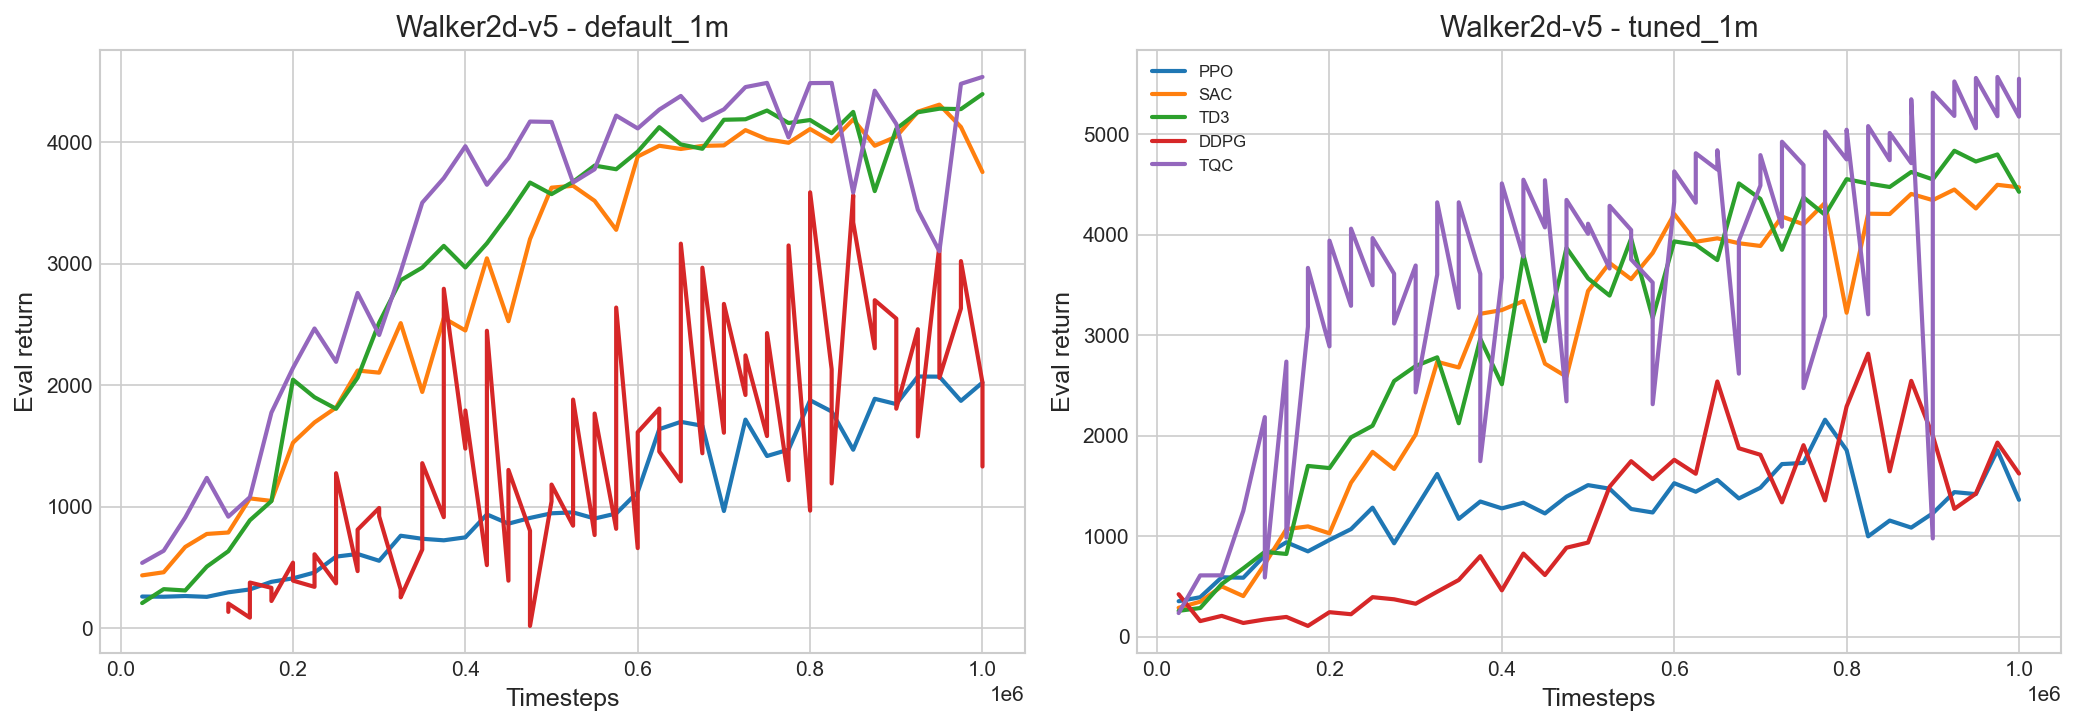

In [12]:
curve_frames = []
for path in pu.RESULTS_RAW.glob(f"{ENV_ID}__*__train_eval.csv"):
    try:
        curve_frames.append(pd.read_csv(path))
    except Exception:
        pass

if curve_frames:
    curves = pd.concat(curve_frames, ignore_index=True)
    curves = curves[curves["track"].isin(["default_1m", "tuned_1m"])]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    for ax, track in zip(axes, ["default_1m", "tuned_1m"]):
        part = curves[curves["track"] == track]
        for algo in pu.ALGORITHMS:
            g = part[part["algorithm"] == algo]
            if g.empty:
                continue
            mean_curve = g.groupby("timestep")["eval_mean_return"].mean()
            ax.plot(mean_curve.index, mean_curve.values, label=algo)
        ax.set_title(f"{ENV_ID} - {track}")
        ax.set_xlabel("Timesteps")
        ax.set_ylabel("Eval return")
    axes[-1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No training curve CSVs found for this environment.")


## Final evaluation for this environment

This table uses the final evaluation results for this environment. It summarizes:

- average return
- fall rate
- average episode length
- number of evaluated runs

This closes the environment notebook and provides the values used later in the
global statistics and report figures.

In [13]:
eval_path = pu.RESULTS_PROCESSED / "final_eval_all.csv"
if eval_path.exists():
    eval_df = pd.read_csv(eval_path)
    env_eval = eval_df[eval_df["env_id"] == ENV_ID]
    summary = (env_eval.groupby(["track", "algorithm"])
               .agg(runs=("run_id", "nunique"),
                    mean_return=("mean_return", "mean"),
                    mean_fall_rate=("fall_rate", "mean"),
                    mean_ep_length=("mean_ep_length", "mean"))
               .reset_index())
    display(summary.round(3))
else:
    print("Run the evaluation notebook after training.")


,track,algorithm,runs,mean_return,mean_fall_rate,mean_ep_length
0,default_1m,DDPG,3,1485.436,0.883,400.067
1,default_1m,PPO,3,2119.494,0.650,609.383
2,default_1m,SAC,5,3712.535,0.150,885.880
3,default_1m,TD3,3,4367.467,0.000,1000.000
4,default_1m,TQC,3,4521.085,0.017,987.800
5,tuned_1m,DDPG,3,1928.169,0.817,474.383
6,tuned_1m,PPO,3,1339.812,1.000,350.233
7,tuned_1m,SAC,3,4473.019,0.000,1000.000
8,tuned_1m,TD3,3,4544.000,0.200,955.183
9,tuned_1m,TQC,3,5297.083,0.000,1000.000
